## Data Engineering: Data Ingestion Using Web-Scraping

In [13]:
import pandas as pd
import requests

# 1. Construct the raw URL for the CSV file on GitHub
kpi_per_day = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/kpi_per-day-shifts.csv"
data_by_customer = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/data-by-customer.csv"
data_by_date = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/data-by-date.csv"
data_by_product = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/data-by-product.csv"

# gold_ml_features = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/gold_ml-ready_customer-features.csv"
# ^This will be for the MLOps part

# 2. Read the CSV directly into a Pandas DataFrame
df1 = pd.read_csv(kpi_per_day)
df2 = pd.read_csv(data_by_customer)
df3 = pd.read_csv(data_by_date)
df4 = pd.read_csv(data_by_product)
# df5 = pd.read_csv(gold_ml_features)

In [68]:
# Preliminary Data Checks & Cleaning

# DataFrames to go over
dataframes_to_clean = [df1, df2, df3, df4]
dataframe_names = ['df1', 'df2', 'df3', 'df4']

# The Main Work
for idx, df_current in enumerate(dataframes_to_clean):
    # Handle 'date' column: convert to datetime and set as Index
    if 'date' in df_current.columns and df_current.index.name != 'date':
        df_current['date'] = pd.to_datetime(df_current['date'])
        df_current.set_index('date', inplace = True)
    # If the Index is not a DatetimeIndex and no 'date' column was found, try converting the existing Index
    elif not isinstance(df_current.index, pd.DatetimeIndex):
        df_current.index = pd.to_datetime(df_current.index)

    # Dropping Rows with NA Values
    df_current.dropna(inplace = True)

    # Dropping Duplicate Rows
    df_current.drop_duplicates(inplace = True)

    # Will re-assign to ensure global variables reflect changes
    if idx == 0:
        df1 = df_current
    elif idx == 1:
        df2 = df_current
    elif idx == 2:
        df3 = df_current
    elif idx == 3:
        df4 = df_current



---

## **Customer Analytics, Time Analysis, Product Analysis, Statistical Modeling & Analysis** Across the Various Datasets

---

### Weekly Analysis

In [23]:
# Classifying each Date into a Week within the Timeframe
if 'date' in df1.columns:
    df1['date'] = pd.to_datetime(df1['date'])
    df1 = df1.set_index('date')
elif not isinstance(df1.index, pd.DatetimeIndex):
    df1.index = pd.to_datetime(df1.index) # Ensuring a DateTime Index

# Calculating the Relative Week number starting from 1
start_date = df1.index.min()
df1['week'] = (df1.index - start_date).days // 7 + 1

,franchiseID,total_earnings,pct_change_earnings_per_day,total_earnings_per_unit,pct_change_total_earnings_per_unit_per_day,avg_quantity_bought,pct_change_avg_quantity_bought_per_day,week
date,,,,,,,,
2024-05-12,3000047,228,216.67,9,200.00,25.333333,5.56,2
2024-05-13,3000047,96,-57.89,6,-33.33,16.000000,-36.84,2
2024-05-14,3000047,240,150.00,12,100.00,20.000000,25.00,2
2024-05-15,3000047,420,75.00,12,0.00,35.000000,75.00,3
2024-05-16,3000047,324,-22.86,9,-25.00,36.000000,2.86,3


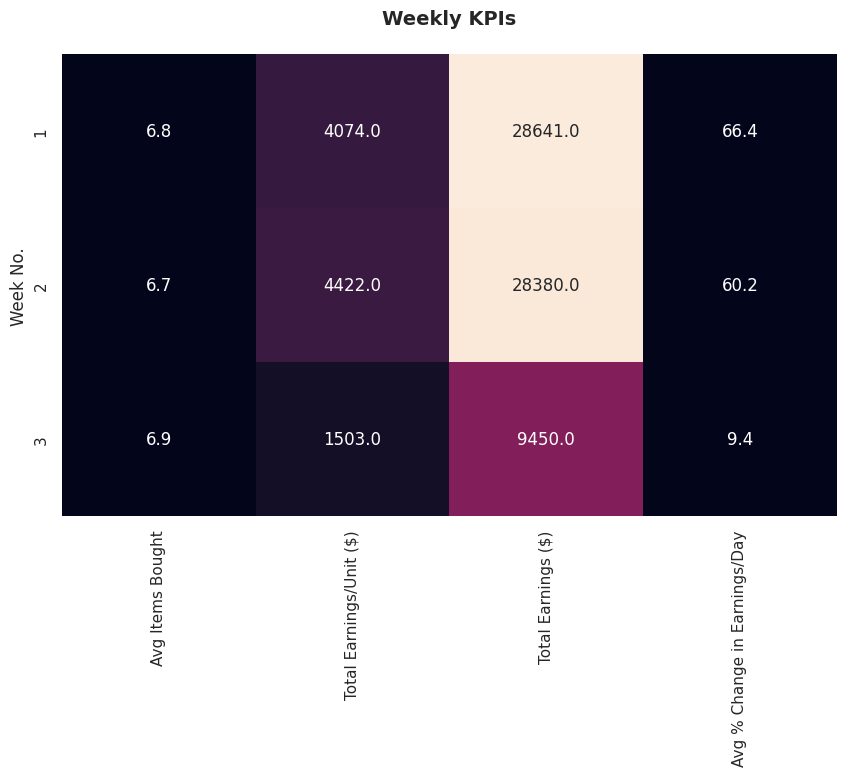

In [49]:
# Weekly Breakdown

weekly_calcs = df1.groupby('week').agg({
      'avg_quantity_bought': 'mean',
      'total_earnings_per_unit': 'sum',
      'total_earnings': 'sum',
      'pct_change_earnings_per_day': 'mean'
    }).round(2).rename(columns={
        'avg_quantity_bought': 'Avg Items Bought',
        'total_earnings_per_unit': 'Total Earnings/Unit ($)',
        'total_earnings': 'Total Earnings ($)',
        'pct_change_earnings_per_day': 'Avg % Change in Earnings/Day'
    })

plt.figure(figsize = (10, 6))
sns.heatmap(weekly_calcs, annot = True,
            fmt = '1.1f',
            cbar = False)
plt.xticks(rotation = 90)
plt.ylabel('Week No.')
plt.title('Weekly KPIs\n',
          fontsize = 14,
          fontweight = 'bold')
plt.show()



---

### Daily Analysis

<Figure size 1300x700 with 0 Axes>

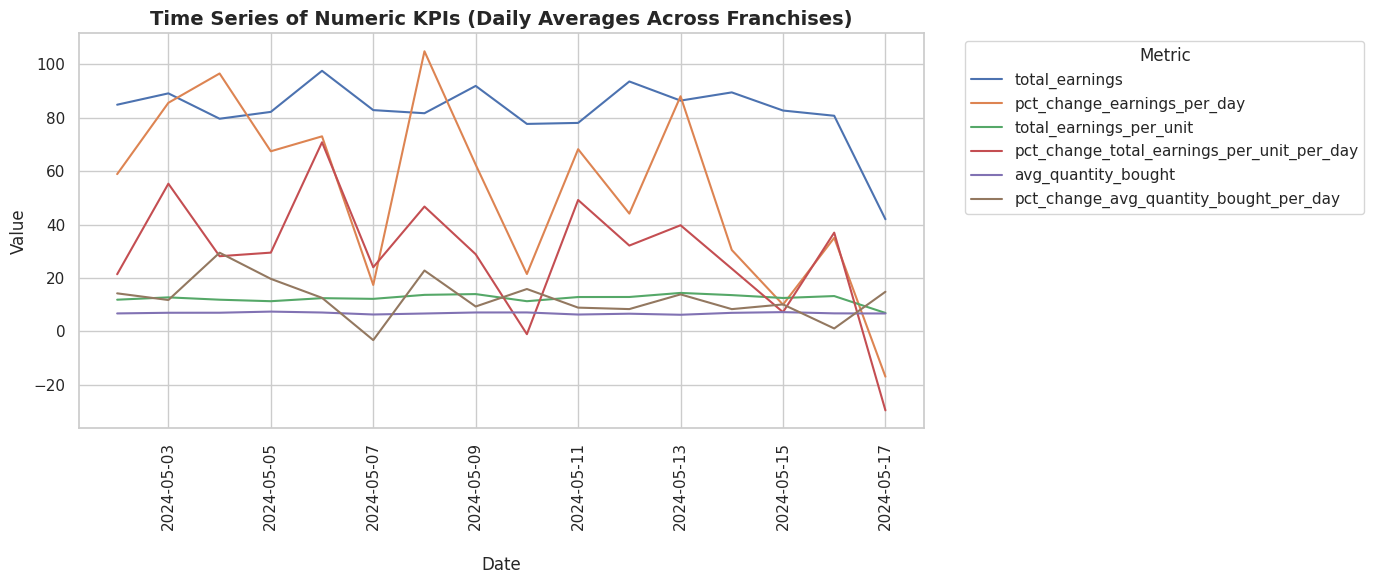

In [126]:

plt.figure(figsize = (13, 7))

# All Numeric (KPI) column
cols_to_plot = [col for col in df1.columns if pd.api.types.is_numeric_dtype(df1[col])]
if 'franchiseID' in cols_to_plot:
    cols_to_plot.remove('franchiseID')
if 'week' in cols_to_plot:
    cols_to_plot.remove('week')

# Indexing by Unique Date
df_aggregated = df1[cols_to_plot].groupby(df1.index).mean()

# Iterating through each selected column and Plotting
plt.figure(figsize = (14, 6))
for col in cols_to_plot:
    sns.lineplot(data = df_aggregated, x = df_aggregated.index, y = col, label=col)

plt.xlabel('\nDate')
plt.ylabel('Value')
plt.xticks(rotation = 90)
plt.title('Time Series of Numeric KPIs (Daily Averages Across Franchises)', fontsize = 14, fontweight = 'bold')
plt.legend(title = 'Metric', bbox_to_anchor = (1.04, 1), loc='upper left') # Place legend outside
plt.grid(True)
plt.tight_layout()
plt.show()

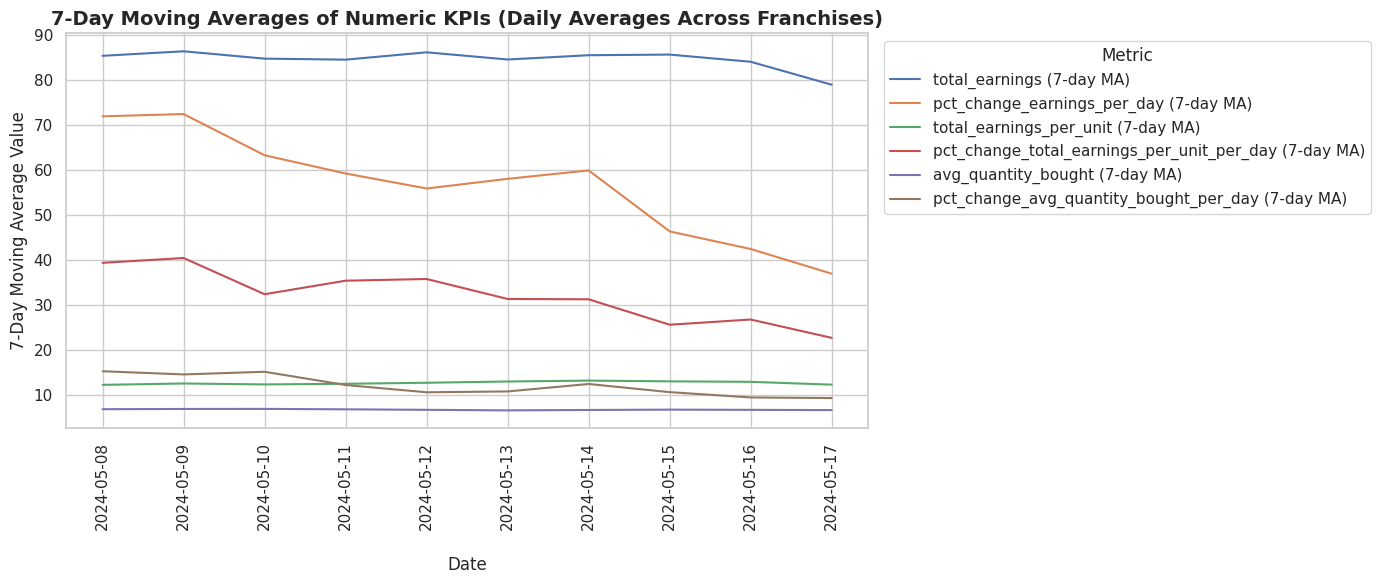

In [123]:
# Moving Averages of Daily KPIs
# Calculate 7-day Rolling Averages for the Aggregated Data

df_rolling_avg = df_aggregated.rolling(window=7, center=False).mean()

plt.figure(figsize = (14, 6))
for col in cols_to_plot:
    sns.lineplot(data = df_rolling_avg, x = df_rolling_avg.index, y = col, label=f'{col} (7-day MA)')

plt.xlabel('\nDate')
plt.ylabel('7-Day Moving Average Value')
plt.xticks(rotation = 90)
plt.title('7-Day Moving Averages of Numeric KPIs (Daily Averages Across Franchises)', fontsize = 14, fontweight = 'bold')
plt.legend(title = 'Metric', bbox_to_anchor = (1.01, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

**The Graph of Moving Averages provides a better picture of KPI trends**

* Average Earnings by Day have been steadily declining as the days pass
* Although, despite this^, Average Quantity of Items bought and Earnings per Item Unit have remained quite steady (although they are low in Raw amount and count, so the Overall Earnings per Day might be reflecting that)



---

### General Analyses

* Customer Lifetime Value (LTV)
* Customers' Spending Patterns
* Correlation Analysis of Specific KPIs
* Best-Performing Franchises

In [88]:
# Had to fix a Surprising issue that came up (Indexing)
# Suggests maybe the Data Pipeline needs some Fixing

# df2 = df2.reset_index().drop(columns = 'index').set_index('customerID')

pd.set_option('display.max_columns', None)

# Let's JOIN the two Best Tables for Customer-specific Insights
customers = pd.merge(df2, df5, on = 'customerID', how = 'inner').set_index('customerID')

customers.head(4)

,total_purchases,unique_products_bought,total_products_bought,total_spent,customer_value_quintile,total_transactions,lifetime_spend,avg_transaction_value,avg_unit_price,total_items,avg_items_per_transaction,unique_products,unique_franchises,payment_method_diversity,first_purchase,last_purchase,recency_days,customer_lifetime_days,avg_days_between_purchases,active_days,active_months,revenue_per_order,avg_basket_size,avg_monthly_spend,multi_franchise_customer,high_value_customer,churn_label
customerID,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000000,9,4,67,201,3,9,201,22.33,3,67,7.44,4,8,3,2024-05-01T03:46:20.875Z,2024-05-15T16:40:28.203Z,785,14,1.75,7,1,22.33,7.44,201,1,0,1
2000001,8,4,51,153,4,8,153,19.13,3,51,6.38,4,7,3,2024-05-07T11:58:30.272Z,2024-05-16T11:27:15.640Z,784,9,1.29,4,1,19.13,6.38,153,1,0,1
2000002,17,5,109,327,1,17,327,19.24,3,109,6.41,5,15,3,2024-05-01T19:01:45.183Z,2024-05-16T14:38:18.782Z,784,15,0.94,12,1,19.24,6.41,327,1,1,1
2000003,13,5,72,216,3,13,216,16.62,3,72,5.54,5,10,3,2024-05-04T15:43:27.910Z,2024-05-17T11:01:41.673Z,783,13,1.08,10,1,16.62,5.54,216,1,0,1


In [97]:
# Feature Engineering another Key Metric

customers['customer_lifetime_value'] = customers['revenue_per_order'] * customers['avg_days_between_purchases'] * customers['active_days']
customers['expenditure_per_product'] = (customers['lifetime_spend']/customers['unique_products_bought']).round(2)

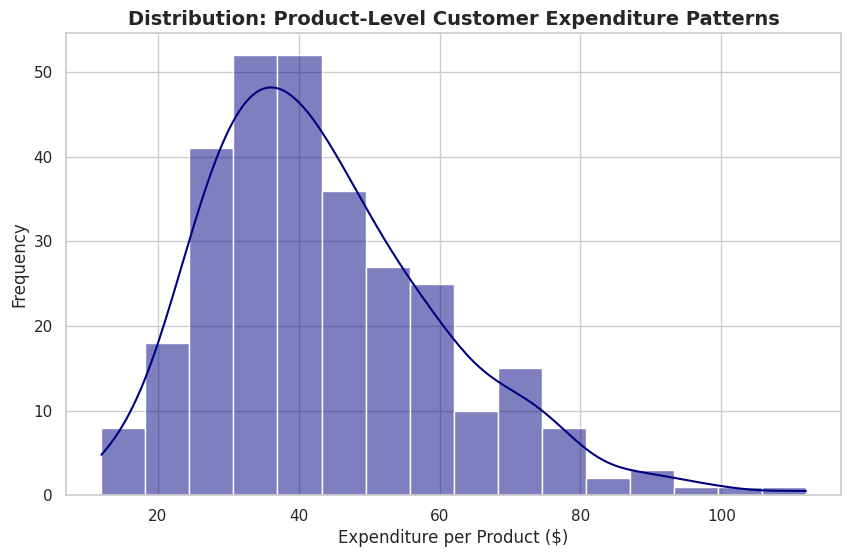

In [95]:
# Customer Spending Histogram
plt.figure(figsize = (10, 6))
sns.histplot(customers['expenditure_per_product'], kde = True, color = 'navy')
plt.xlabel('Expenditure per Product ($)')
plt.ylabel('Frequency')
plt.title('Distribution: Product-Level Customer Expenditure Patterns', fontsize = 14, fontweight = 'bold')
plt.show()

Wow. The Average Customer spends about $40 on an item?

A closer analysis might be needed, as some customers might buy luxurious or higher-priced and less-needed-in-amount items only.

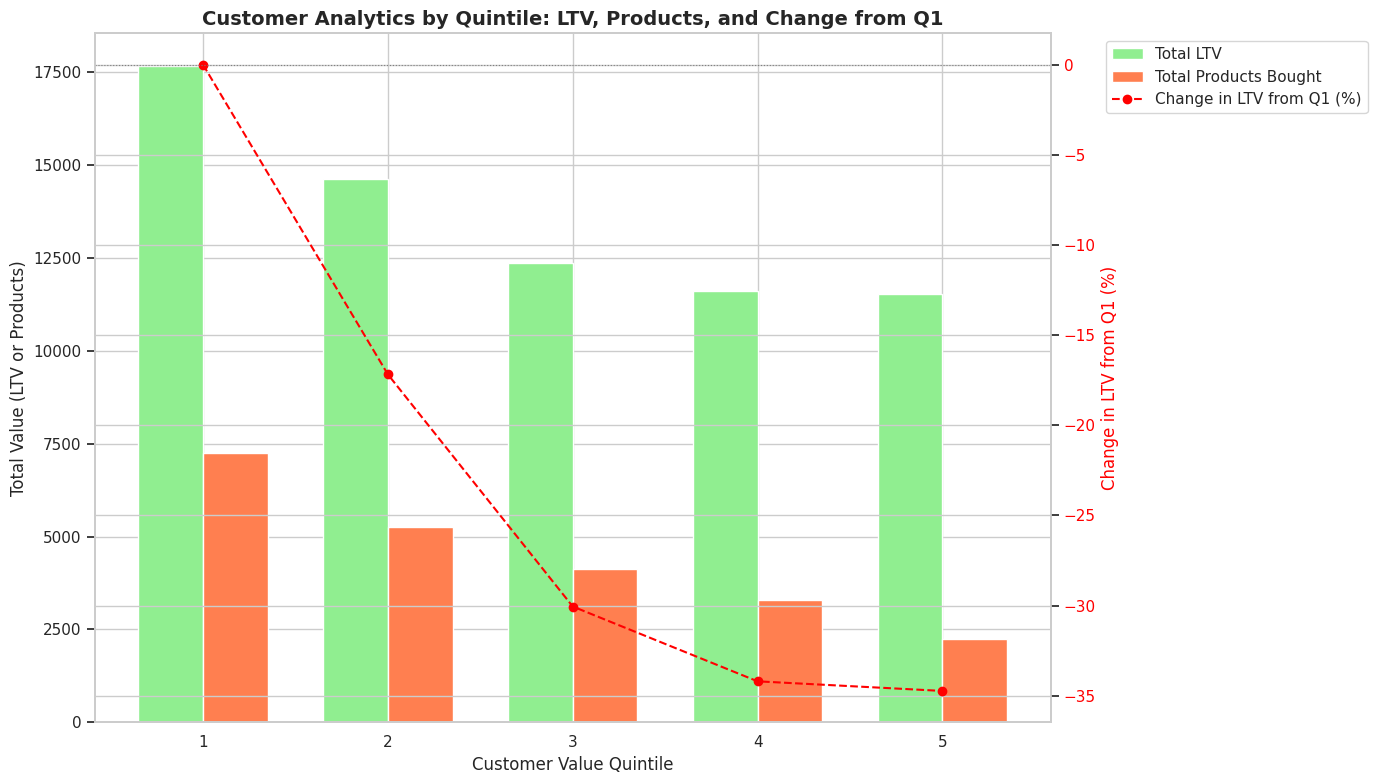

In [118]:
# Customers were Classified into Quintiles based on Revenue Earned from them (i.e., How much they Spent on the Business)
# Let's Inspect them

# Sort by index (quintile number) to ensure the x-axis is ordered from 1 to 5
quintile_ltv = customers.groupby('customer_value_quintile')['customer_lifetime_value'].sum().sort_index()
quintile_products = customers.groupby('customer_value_quintile')['total_products_bought'].sum().sort_index()

# Get the LTV for Quintile 1
q1_ltv = quintile_ltv.loc[1]

# Calculate the difference for each quintile relative to Quintile 1 (as percentage)
ltv_diffs = ((quintile_ltv - q1_ltv) / q1_ltv) * 100

fig, ax1 = plt.subplots(figsize=(14, 8))

# --- Bar Plots: Total LTV and Total Products Bought by Quintile ---
bar_width = 0.35
index = quintile_ltv.index

# Bar for Total LTV
bar1 = ax1.bar(index - bar_width/2, quintile_ltv.values, bar_width, label='Total LTV', color='lightgreen')
# Bar for Total Products Bought
bar2 = ax1.bar(index + bar_width/2, quintile_products.values, bar_width, label='Total Products Bought', color='coral')

ax1.set_xlabel('Customer Value Quintile')
ax1.set_ylabel('Total Value (LTV or Products)')
ax1.set_title('Customer Analytics by Quintile: LTV, Products, and Change from Q1', fontsize = 14, fontweight = 'bold')
ax1.set_xticks(index)

# Create a second y-axis for the line plot
ax2 = ax1.twinx()

# --- Line Plot: Change from Q1 ---
ax2.plot(quintile_ltv.index, ltv_diffs.values, color = 'red', linestyle = '--', marker = 'o', label = 'Change in LTV from last Quintile (%)')
ax2.set_ylabel('Change in LTV from Q1 (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal line at 0 for the secondary axis
ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8, label='_nolegend_')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

We see Diminishing Decreases in Relative LTV by Quintile.

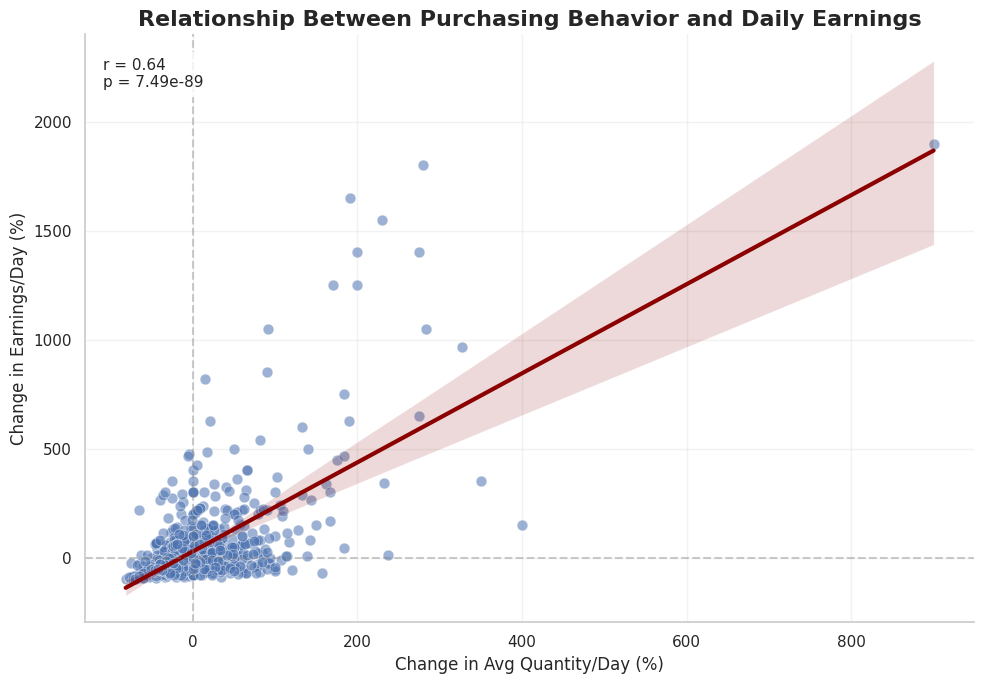

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 7))
sns.regplot(
    data = df1,
    x = "pct_change_avg_quantity_bought_per_day",
    y = "pct_change_earnings_per_day",
    ci = 95, # Confidence Interval = 95%
    scatter_kws = {
        "alpha": 0.55,
        "s": 60,
        "edgecolor": "white",
        "linewidths": 0.5 # Corrected from 'linewidth'
    },
    line_kws = {
        "color": "darkred",
        "linewidth": 3
    }
)

# Adding Correlation Coefficient directly on to the Plot

from scipy.stats import pearsonr

# Dropping NaN values from the relevant columns for Correlation calculation
df_corr = df1.dropna(subset = ["pct_change_avg_quantity_bought_per_day", "pct_change_earnings_per_day"])

r, p = pearsonr(df_corr["pct_change_avg_quantity_bought_per_day"], df_corr["pct_change_earnings_per_day"])

plt.text(
    0.02, 0.96,
    f"r = {r:.2f}\np = {p:.3g}",
    transform = plt.gca().transAxes,
    ha = "left",
    va = "top",
    fontsize = 11,
    bbox = dict(facecolor = "white", alpha = 0.8)
)

# Adding Zero Reference lines (can be Informative with Percentage Change Plots)
# Should Create 4 Quadrants (Quantity-Earnings Relationships)
plt.axhline(0, color = "gray", ls = "--", alpha = 0.4)
plt.axvline(0, color = "gray", ls = "--", alpha = 0.4)

plt.xlabel("Change in Avg Quantity/Day (%)")
plt.ylabel("Change in Earnings/Day (%)")
plt.title(
    "Relationship Between Purchasing Behavior and Daily Earnings",
    fontsize = 16,
    fontweight = "bold"
)

sns.set_theme(style = "whitegrid")
plt.grid(alpha = 0.25)
sns.despine()
plt.tight_layout()
plt.show()

# Correlation Coefficient: +0.64
# Statistically Significant (p < way less than 0.05)

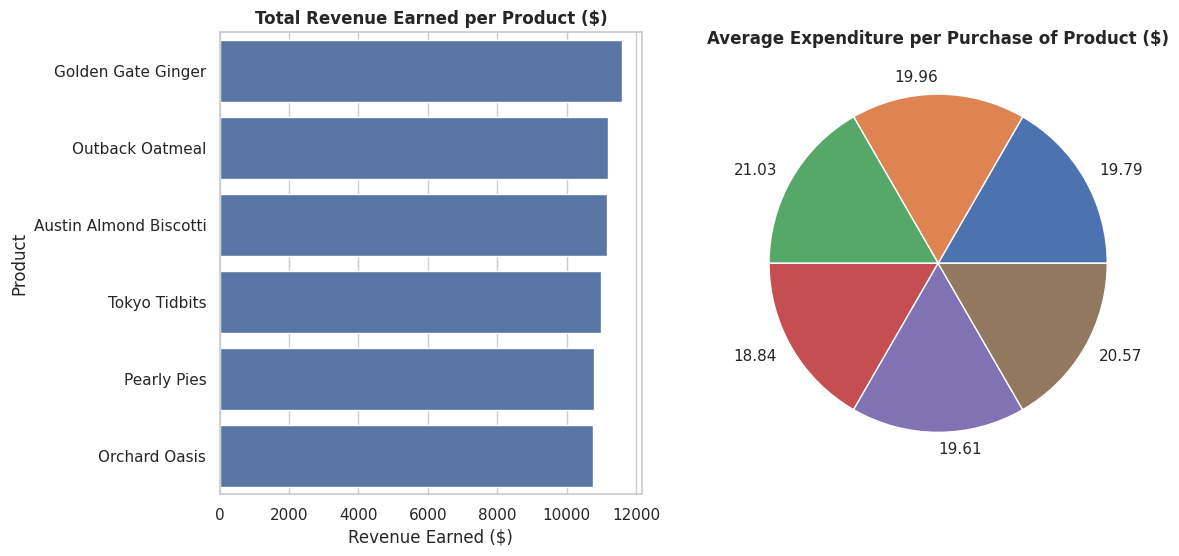

In [166]:
products = df4.reset_index().drop(columns = 'index').set_index('product').sort_values(by = 'total_spent', ascending = False)

plt.figure(figsize = (12, 6))
sns.set_theme(style = "whitegrid")

plt.subplot(1, 2, 1)
sns.barplot(y = products.index, x = products['total_spent'])
plt.xlabel('Revenue Earned ($)')
plt.ylabel('Product')
plt.title("Total Revenue Earned per Product ($)", fontweight = 'bold')

plt.subplot(1, 2, 2)
plt.pie((products['total_spent']/products['total_times_bought']).value_counts(normalize = True),
        labels = (products['total_spent']/products['total_times_bought']).value_counts(normalize = True).index.round(2))
plt.title("Average Expenditure per Purchase of Product ($)", fontweight = 'bold')

plt.show()

All Products seem to be high-earners and little differentiates them.



---

### Basket Analysis

How the Average amount of Items a given Customer buys per Transaction correlates to other key measures such as how much he would spend per item (`expenditure_per_product`) or how much he would spend in total (`total_spent`), etc.

<Figure size 1700x1800 with 0 Axes>

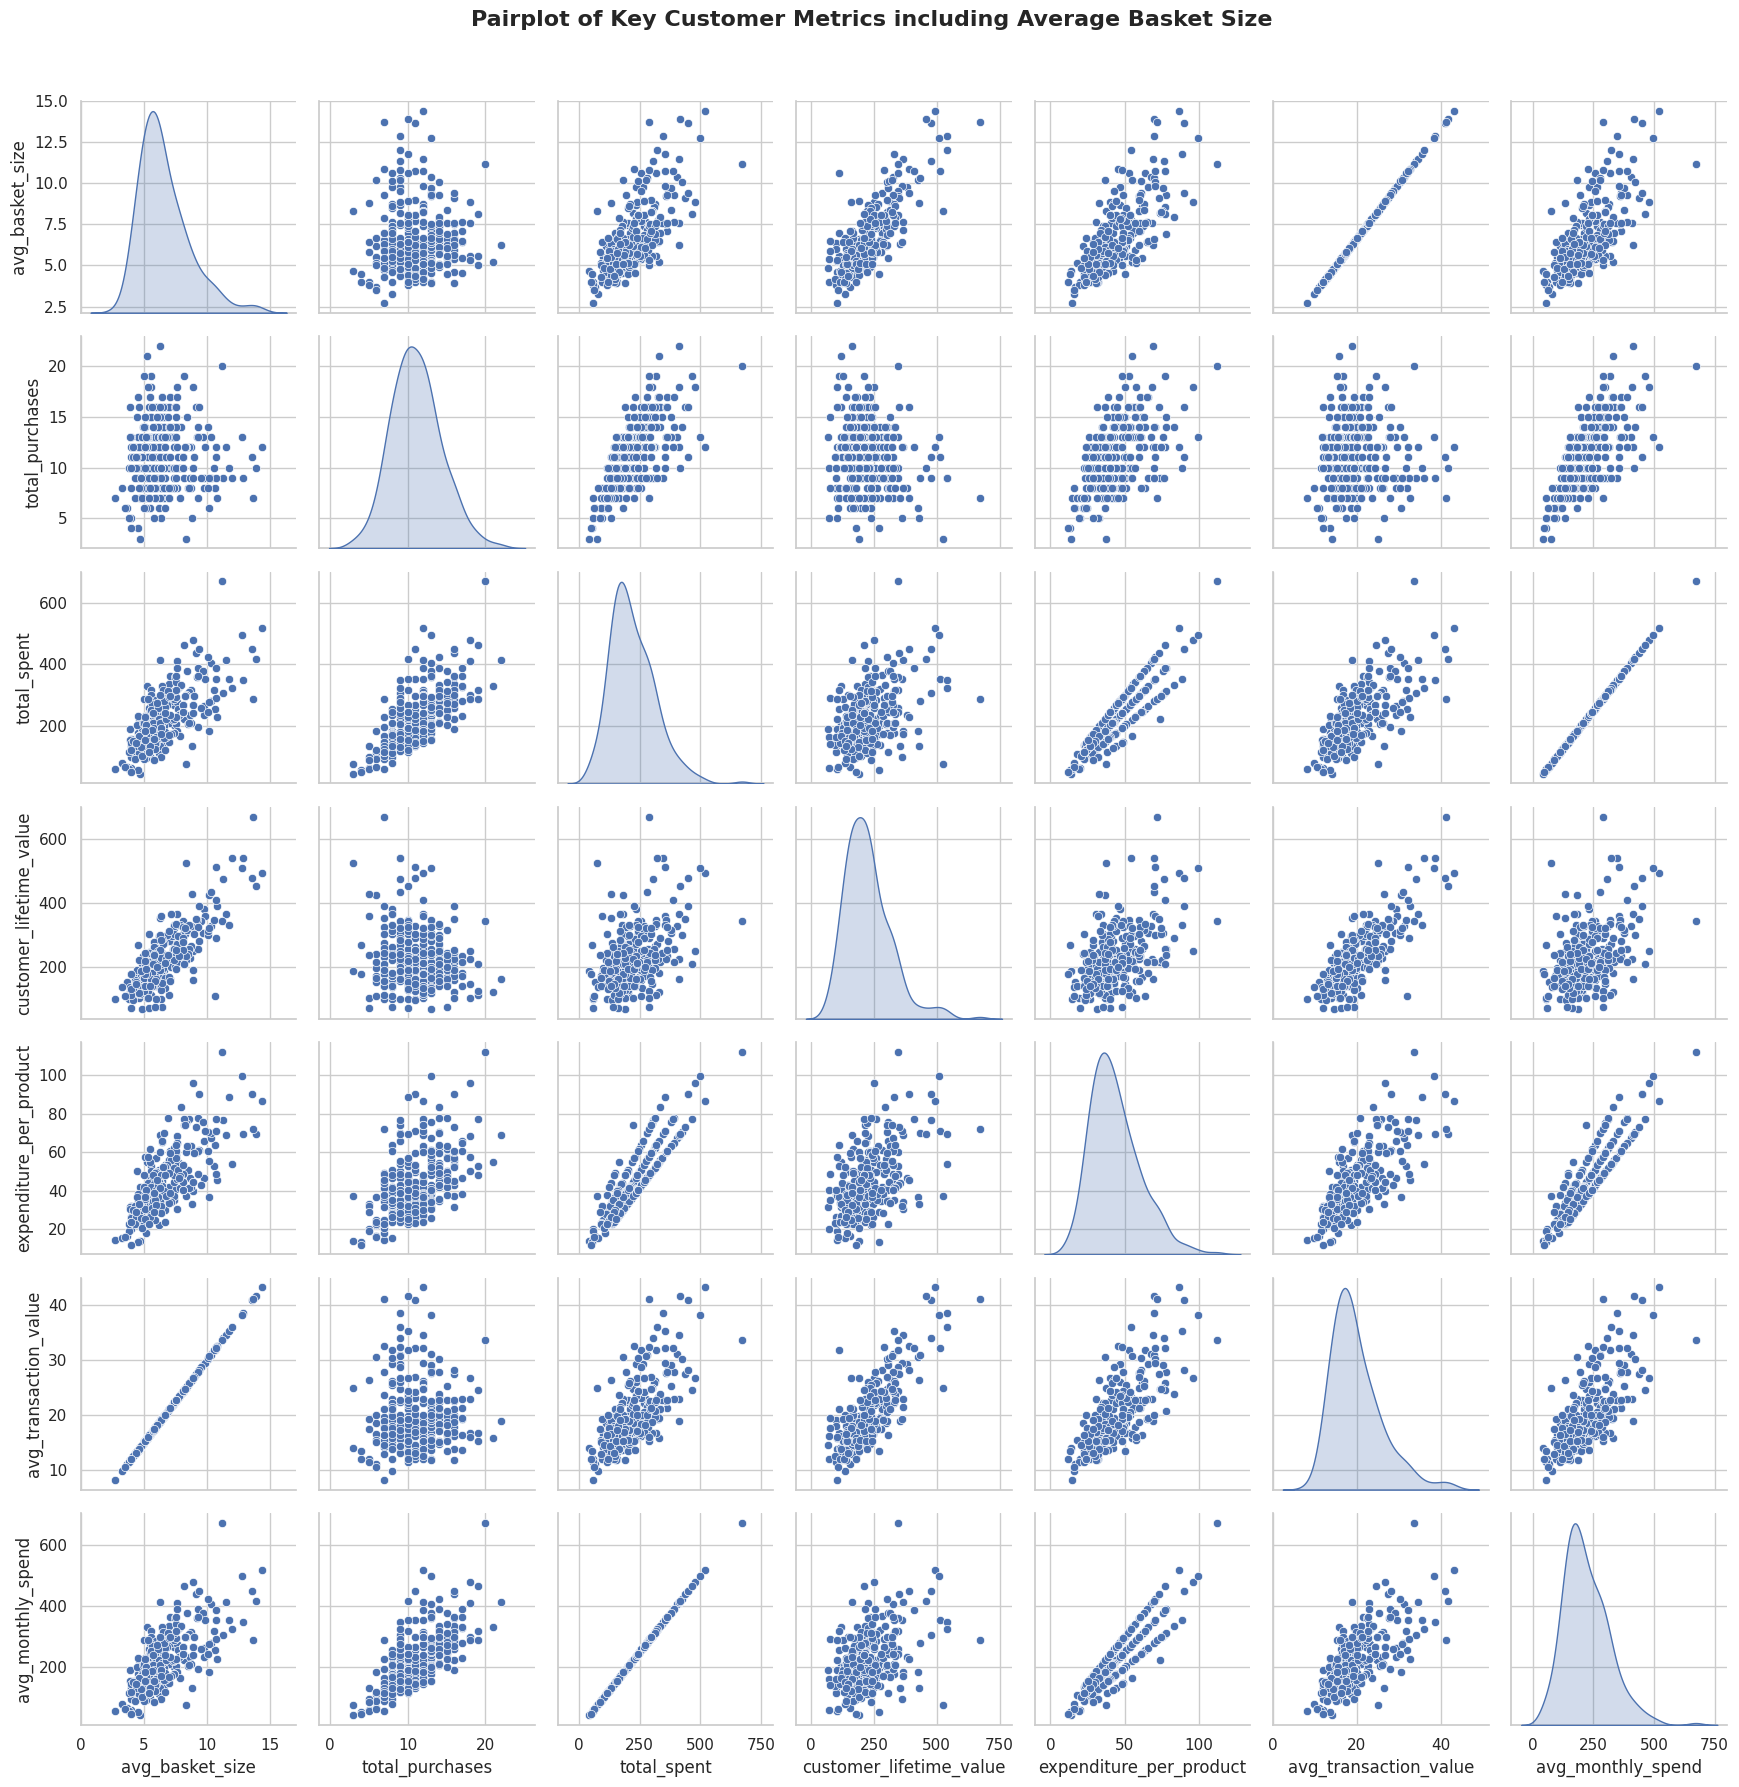

In [169]:
# Basket Size - Average amount of Items a Customer buys in a given Purchase/Transaction
# Avg Basket Size 'avg_basket_size' and 5-7 other key Numerical Metrics for the Pairplot
key_metrics = [
    'avg_basket_size',
    'total_purchases',
    'total_spent',
    'customer_lifetime_value',
    'expenditure_per_product',
    'avg_transaction_value',
    'avg_monthly_spend'
]

# Filtering out any columns that might not exist in the Dataframe
existing_key_metrics = [metric for metric in key_metrics if metric in customers.columns]


# The Pairplot
plt.figure(figsize = (17, 18))
sns.pairplot(customers[existing_key_metrics], diag_kind = 'kde')
plt.suptitle('Pairplot of Key Customer Metrics including Average Basket Size', y = 1.02, fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()